# S&P 500 Valuation & Risk Analysis — CSV Version

This notebook uses the uploaded `SP500_Data.csv` only.

Rules applied:
- Only columns available in the CSV are used.
- Forward P/E and other unavailable variables are removed.
- Crash annotations only.
- Every graph is a separate **1×1 single-panel** figure.
- No `3×1`, `2×2`, `4×2`, or dashboard-style subplot panels.


In [1]:
# Optional installs if needed:
# !pip install pandas numpy matplotlib seaborn scipy openpyxl --quiet

import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display

# ── Style ───────────────────────────────────────────────────────────────────
BG      = '#0b1020'
FG      = '#e5e7eb'
GRID    = '#334155'
ACCENT  = '#38bdf8'
GREEN   = '#22c55e'
RED     = '#ef4444'
ORANGE  = '#f97316'
GOLD    = '#facc15'
PURPLE  = '#a78bfa'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': FG,
    'xtick.color': FG,
    'ytick.color': FG,
    'text.color': FG,
    'axes.titlecolor': FG,
    'grid.color': GRID,
    'font.size': 11,
    'axes.titlesize': 15,
    'axes.labelsize': 11,
    'legend.facecolor': BG,
    'legend.edgecolor': GRID,
})

FIG_DIR = Path('sp500_csv_figures')
FIG_DIR.mkdir(exist_ok=True)


## 1. Load uploaded CSV

In [2]:
CSV_PATH = '/mnt/data/SP500_Data.csv'

raw = pd.read_csv(CSV_PATH)

# Clean names and fix known typo in source file
raw.columns = [c.strip() for c in raw.columns]
rename_map = {
    'Price': 'Date',
    'Close': 'SP500_Close',
    'Open': 'SP500_Open',
    'Volume': 'Volume',
    'Trailing P/E': 'Trailing_PE',
    'Divident Yield': 'Dividend_Yield',
    'Divident Yield ': 'Dividend_Yield',
    'Dividend Yield': 'Dividend_Yield',
    'Earning Yield': 'Earnings_Yield',
    'Earnings Yield': 'Earnings_Yield',
    'CAPE': 'CAPE',
}
raw = raw.rename(columns={k: v for k, v in rename_map.items() if k in raw.columns})

# Parse date. Source dates are like 01-01-2000 = day-month-year.
raw['Date'] = pd.to_datetime(raw['Date'], dayfirst=True, errors='coerce')
raw = raw.dropna(subset=['Date']).sort_values('Date').set_index('Date')
raw.index = raw.index.to_period('M').to_timestamp('M')

# Convert all non-date columns to numeric
for c in raw.columns:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')

# Keep only columns with real data
master = raw.dropna(axis=1, how='all').copy()

# Derived columns from available CSV data
if 'SP500_Close' in master.columns:
    master['Monthly_Return'] = master['SP500_Close'].pct_change()
    master['Rolling_12M_Return'] = master['SP500_Close'].pct_change(12) * 100
    master['Rolling_12M_Vol'] = master['Monthly_Return'].rolling(12).std() * np.sqrt(12) * 100
    master['Drawdown'] = (master['SP500_Close'] / master['SP500_Close'].cummax() - 1) * 100

# Final rule: only available columns
master = master.dropna(axis=1, how='all')

print('CSV rows:', len(raw))
print('Available columns used:')
print(list(master.columns))

display(master.head())
display(master.tail())


CSV rows: 318
Available columns used:
['SP500_Close', 'SP500_Open', 'Volume', 'Trailing_PE', 'Dividend_Yield', 'Earnings_Yield', 'CAPE', 'Monthly_Return', 'Rolling_12M_Return', 'Rolling_12M_Vol', 'Drawdown']


,SP500_Close,SP500_Open,Volume,Trailing_PE,Dividend_Yield,Earnings_Yield,CAPE,Monthly_Return,Rolling_12M_Return,Rolling_12M_Vol,Drawdown
Date,,,,,,,,,,,
2000-01-31,1394.459961,1469.250000,2.149440e+10,27.3692,1.17,3.44,43.77,NaN,NaN,NaN,0.000000
2000-02-29,1366.420044,1394.459961,2.091200e+10,26.8188,1.21,3.60,42.19,-0.020108,NaN,NaN,-2.010808
2000-03-31,1498.579956,1366.420044,2.615620e+10,29.4128,1.16,3.53,43.22,0.096720,NaN,NaN,0.000000
2000-04-30,1452.430054,1498.579956,2.010646e+10,27.9744,1.15,3.51,43.53,-0.030796,NaN,NaN,-3.079576
2000-05-31,1420.599976,1452.430054,1.989830e+10,27.3613,1.18,3.64,41.97,-0.021915,NaN,NaN,-5.203592


,SP500_Close,SP500_Open,Volume,Trailing_PE,Dividend_Yield,Earnings_Yield,CAPE,Monthly_Return,Rolling_12M_Return,Rolling_12M_Vol,Drawdown
Date,,,,,,,,,,,
2026-02-28,6878.879883,6916.640137,1.140000e+11,29.3894,1.14,3.40,38.93,-0.008668,15.524055,10.747282,-0.866834
2026-03-31,6528.520020,6824.359863,1.290000e+11,27.8925,1.19,3.52,36.91,-0.050933,16.334540,10.287408,-5.915953
2026-04-30,7209.009766,6556.560059,1.060000e+11,30.7800,1.13,3.36,37.96,0.104233,29.447513,13.431176,0.000000
2026-05-31,7580.060059,7234.540039,1.130000e+11,25.2000,1.06,3.16,40.16,0.051470,28.221543,13.146411,0.000000
2026-06-30,7511.350098,7582.290039,6.999880e+10,25.2700,1.06,3.13,41.02,-0.009065,21.054156,13.090718,-0.906457


## 2. Crash-only annotations

In [3]:
# Crash-only annotations. Non-crash macro/policy events are intentionally excluded.
CRASH_EVENTS = [
    ('2000-03-31', 'Dot-com peak'),
    ('2001-09-30', '9/11 shock'),
    ('2002-10-31', 'Dot-com trough'),
    ('2008-09-30', 'Lehman collapse'),
    ('2009-03-31', 'GFC bottom'),
    ('2011-08-31', 'US downgrade shock'),
    ('2015-08-31', 'China devaluation shock'),
    ('2018-12-31', 'Q4 2018 selloff'),
    ('2020-03-31', 'COVID crash'),
    ('2022-10-31', 'Inflation bear low'),
]

def events_in_range(index):
    if len(index) == 0:
        return []
    lo, hi = index.min(), index.max()
    out = []
    for d, label in CRASH_EVENTS:
        dt = pd.to_datetime(d).to_period('M').to_timestamp('M')
        if lo <= dt <= hi:
            out.append((dt, label))
    return out

def annotate_crashes(ax, index):
    for dt, label in events_in_range(index):
        ax.axvline(dt, color=RED, lw=0.9, alpha=0.55, ls='--')
        ymin, ymax = ax.get_ylim()
        y = ymax - 0.08 * (ymax - ymin)
        ax.text(dt, y, label, rotation=90, va='top', ha='right', fontsize=8, color=FG, alpha=0.85)

def format_time_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.25)
    for spine in ax.spines.values():
        spine.set_alpha(0.4)

def save_single_panel(fig, filename):
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=160, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

def plot_single_series(series, title, ylabel, filename, color=ACCENT, hline=None, hline_label=None, fill=False, percent=False):
    s = series.dropna()
    if s.empty:
        print(f'Skipping {title}: no data available.')
        return

    fig, ax = plt.subplots(figsize=(15, 6), facecolor=BG)  # 1×1 single panel only
    ax.plot(s.index, s.values, lw=1.5, color=color, label=series.name or title)

    if fill:
        ax.fill_between(s.index, s.values, alpha=0.18, color=color)

    if hline is not None:
        ax.axhline(hline, color=GOLD, lw=1.0, ls='--', label=hline_label or str(hline))
        ax.legend(loc='best')

    if percent:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())

    ax.set_title(title, loc='left', fontweight='bold')
    ax.set_ylabel(ylabel)
    annotate_crashes(ax, s.index)
    format_time_axis(ax)
    save_single_panel(fig, filename)


## 3. Available descriptive statistics only

In [4]:
def extended_describe(df):
    df = df.dropna(axis=1, how='all')
    if df.empty:
        return pd.DataFrame()
    d = df.describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).T
    d['skewness'] = df.skew(numeric_only=True)
    d['kurtosis'] = df.kurt(numeric_only=True)
    d['median'] = df.median(numeric_only=True)
    d['IQR'] = df.quantile(0.75) - df.quantile(0.25)
    return d.round(4)

# Stats only for columns that exist and have at least 12 observations
stat_cols = [
    c for c in master.select_dtypes(include=[np.number]).columns
    if master[c].notna().sum() >= 12
]

stats_table = extended_describe(master[stat_cols])

print('Statistics columns used:')
print(stat_cols)

if stats_table.empty:
    print('No statistics available.')
else:
    display(stats_table)


Statistics columns used:
['SP500_Close', 'SP500_Open', 'Volume', 'Trailing_PE', 'Dividend_Yield', 'Earnings_Yield', 'CAPE', 'Monthly_Return', 'Rolling_12M_Return', 'Rolling_12M_Vol', 'Drawdown']


,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,max,skewness,kurtosis,median,IQR
SP500_Close,318.0,2.367708e+03,1.596669e+03,7.350900e+02,9.192930e+02,1.055169e+03,1.221342e+03,1.583380e+03,2.971110e+03,4.653620e+03,5.918111e+03,7.580060e+03,1.3691,1.0194,1.583380e+03,1.749767e+03
SP500_Open,318.0,2.349702e+03,1.571093e+03,7.295700e+02,9.228940e+02,1.053650e+03,1.221352e+03,1.557485e+03,2.973562e+03,4.605160e+03,5.897667e+03,7.582290e+03,1.3571,0.9688,1.557485e+03,1.752210e+03
Volume,318.0,7.230381e+10,2.947663e+10,1.908910e+10,2.486145e+10,2.778174e+10,5.114003e+10,7.666162e+10,8.841450e+10,1.083000e+11,1.173000e+11,1.620000e+11,0.0317,-0.1500,7.666162e+10,3.727447e+10
Trailing_PE,318.0,2.601860e+01,1.562050e+01,1.300780e+01,1.580680e+01,1.656180e+01,1.867860e+01,2.281480e+01,2.728070e+01,3.328550e+01,4.494940e+01,1.224128e+02,4.3993,22.0053,2.281480e+01,8.602200e+00
Dividend_Yield,318.0,1.788300e+00,3.899000e-01,1.060000e+00,1.178500e+00,1.277000e+00,1.560000e+00,1.800000e+00,1.997500e+00,2.123000e+00,2.253000e+00,3.600000e+00,1.0052,3.4764,1.800000e+00,4.375000e-01
Earnings_Yield,318.0,4.411400e+00,1.218600e+00,8.100000e-01,2.358000e+00,3.052000e+00,3.602500e+00,4.395000e+00,5.290000e+00,5.993000e+00,6.361500e+00,7.410000e+00,-0.3214,0.4530,4.395000e+00,1.687500e+00
CAPE,318.0,2.795560e+01,6.024300e+00,1.332000e+01,1.976550e+01,2.098200e+01,2.387250e+01,2.683000e+01,3.122000e+01,3.714800e+01,3.896150e+01,4.377000e+01,0.4265,-0.0059,2.683000e+01,7.347500e+00
Monthly_Return,317.0,6.300000e-03,4.380000e-02,-1.694000e-01,-7.920000e-02,-5.500000e-02,-1.770000e-02,1.130000e-02,3.360000e-02,5.650000e-02,7.550000e-02,1.268000e-01,-0.4812,0.8473,1.130000e-02,5.130000e-02
Rolling_12M_Return,306.0,7.798300e+00,1.655880e+01,-4.475620e+01,-2.389890e+01,-1.558740e+01,-2.964000e-01,1.108580e+01,1.730450e+01,2.618240e+01,2.992080e+01,5.371450e+01,-0.6282,0.7578,1.108580e+01,1.760090e+01
Rolling_12M_Vol,306.0,1.390510e+01,5.643900e+00,3.855400e+00,6.178200e+00,7.411700e+00,9.005900e+00,1.354930e+01,1.807140e+01,2.192220e+01,2.367830e+01,3.041780e+01,0.5230,-0.3362,1.354930e+01,9.065500e+00


## 4. Single-panel time-series graphs

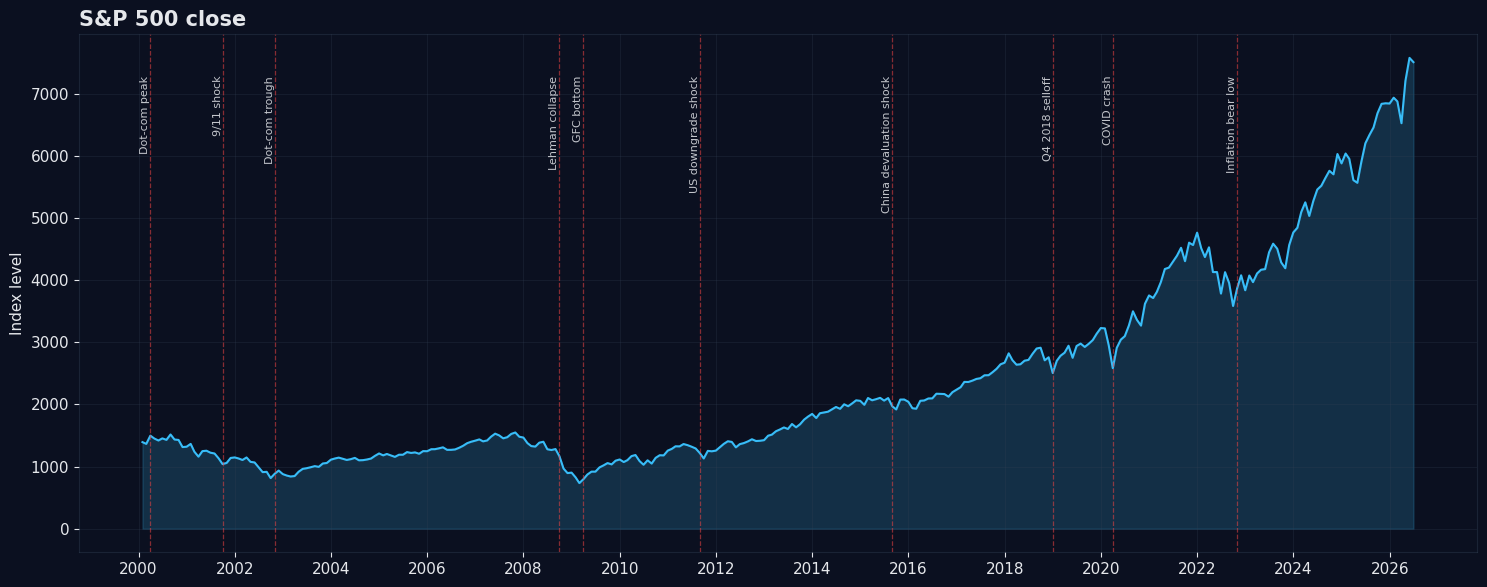

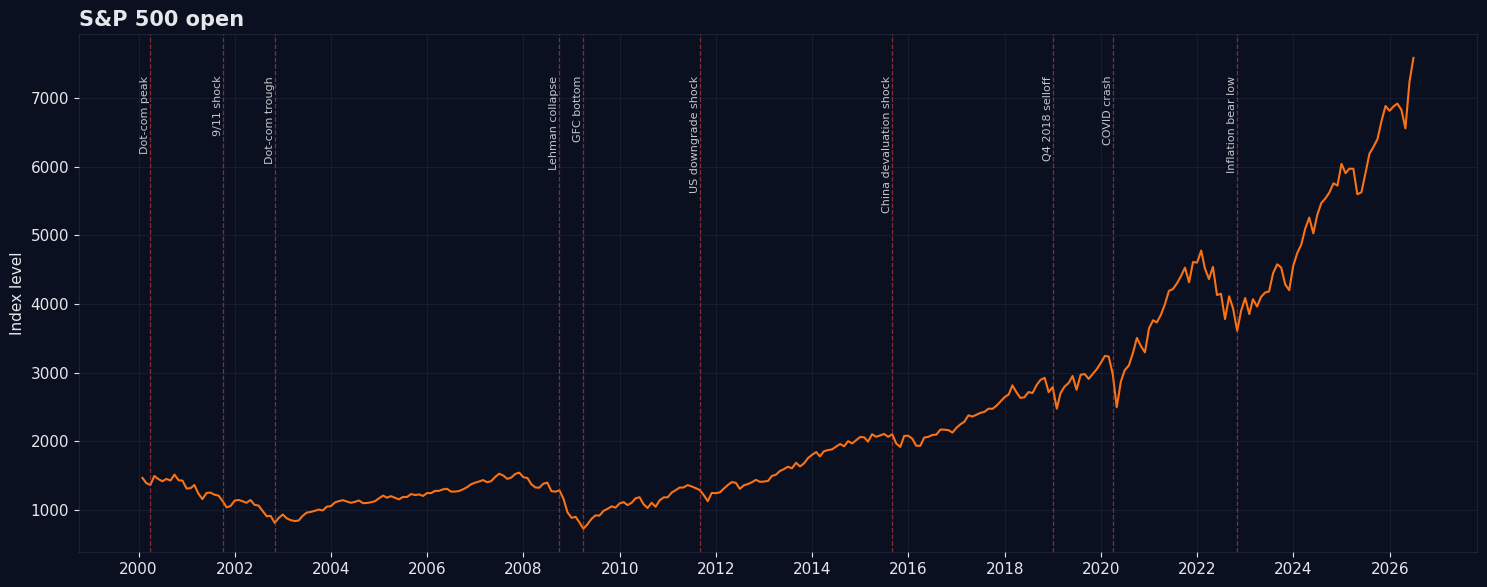

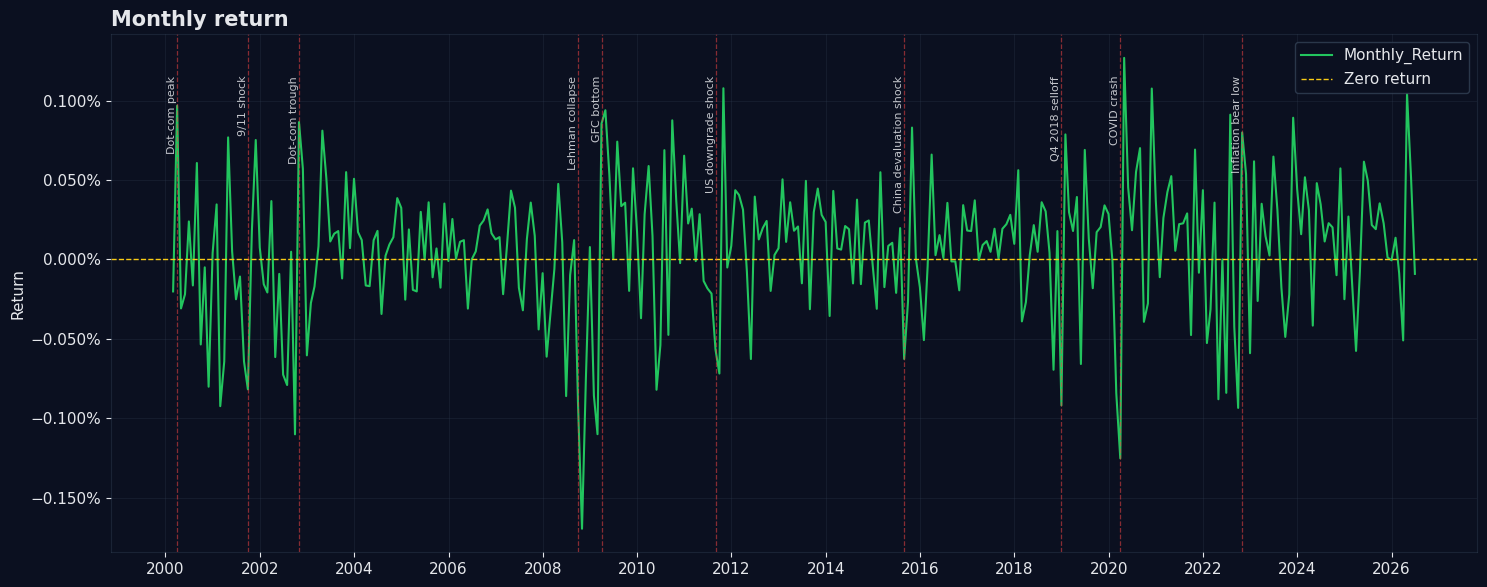

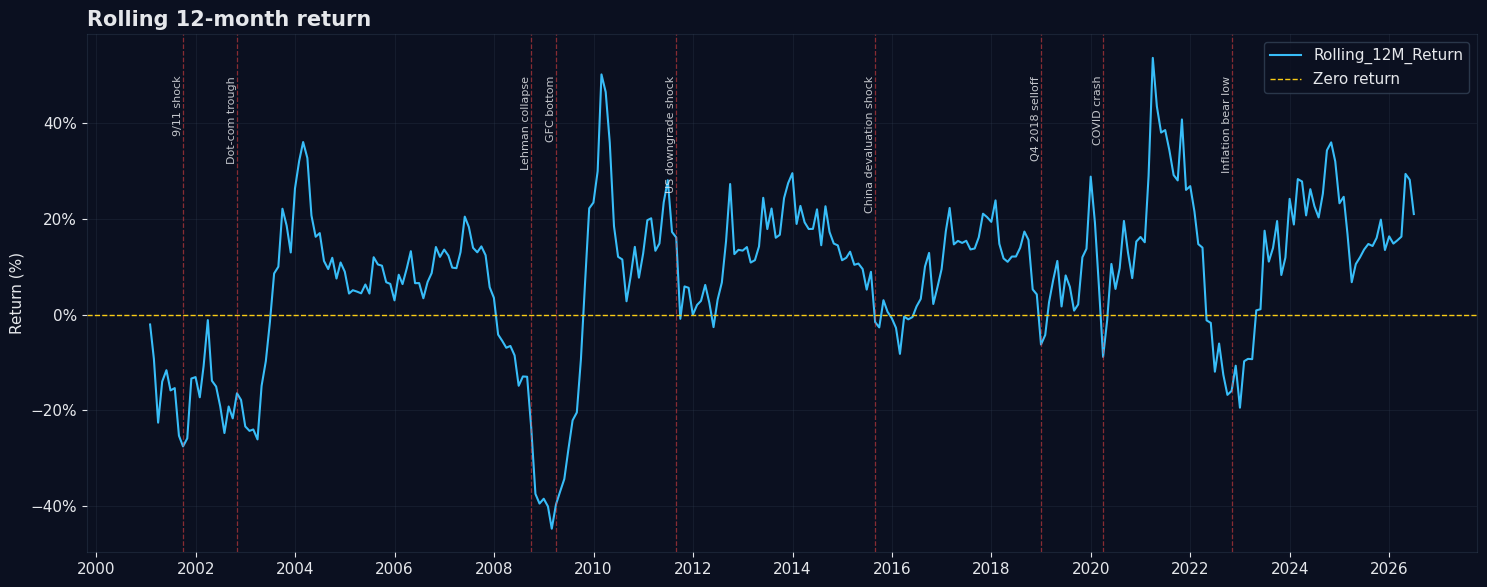

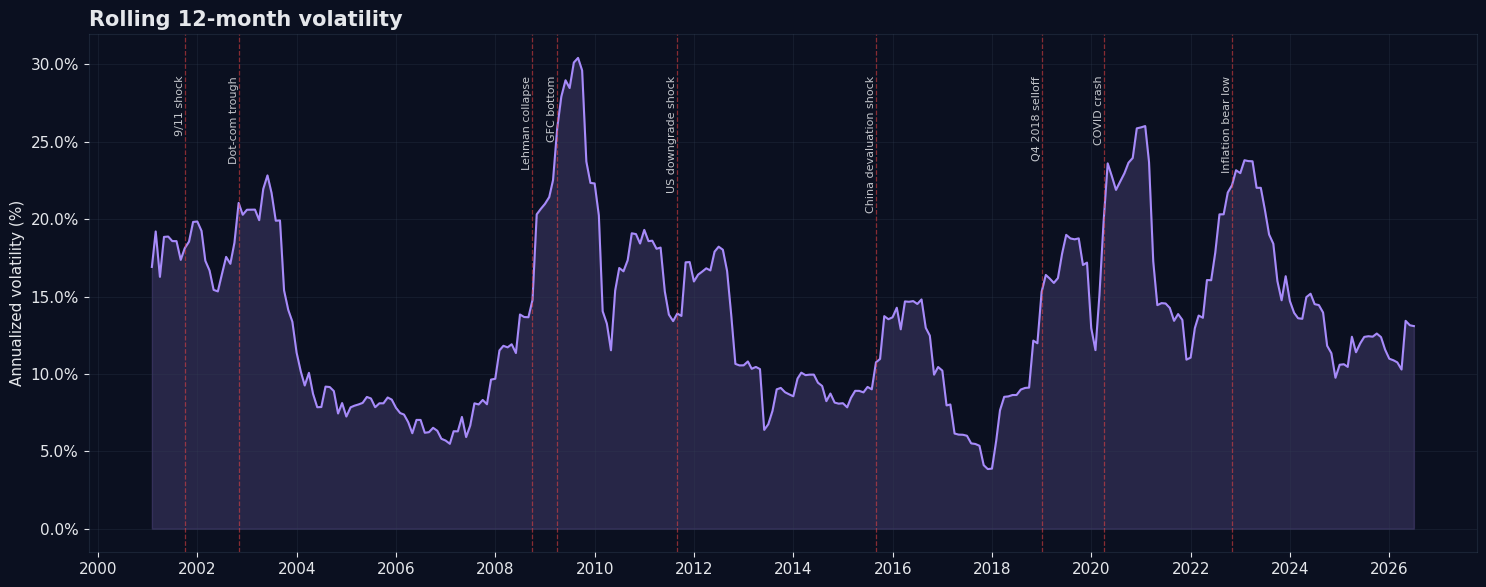

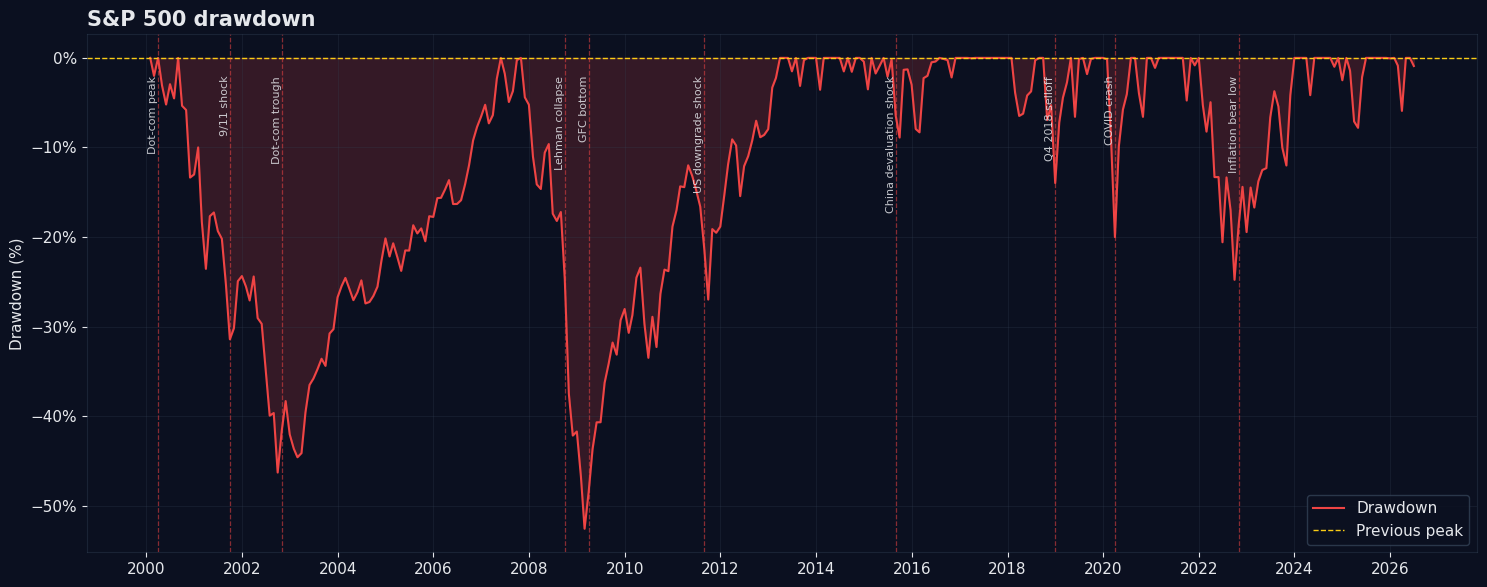

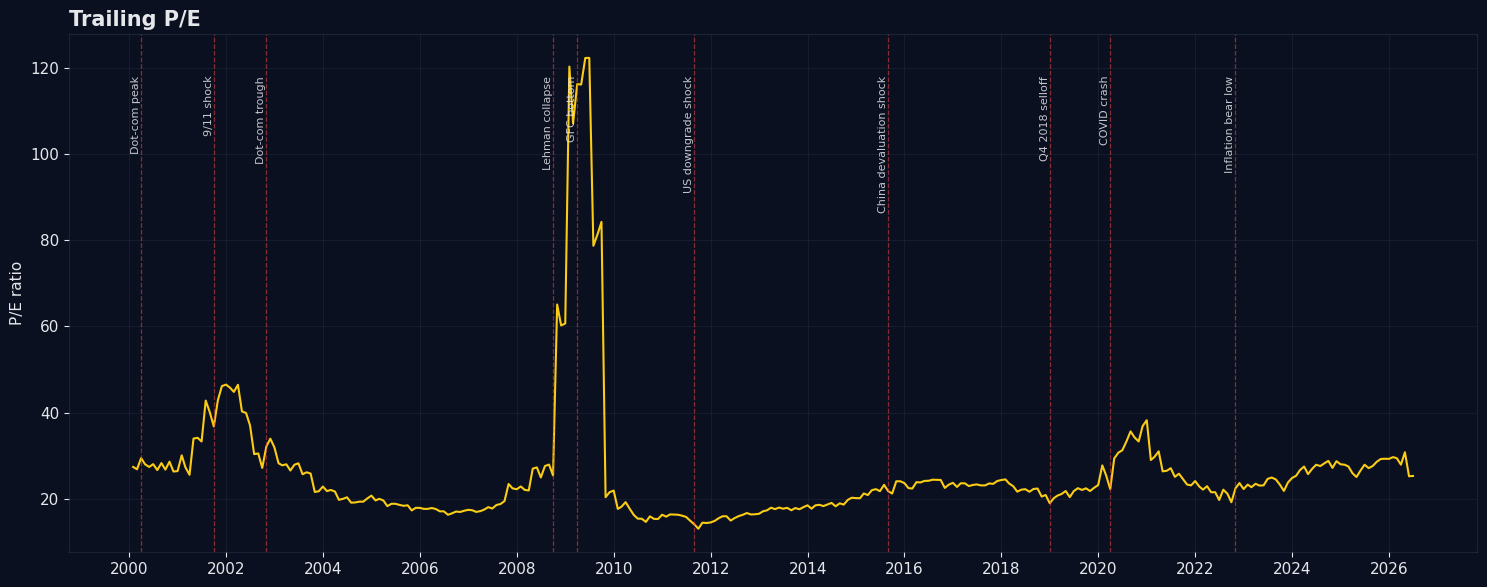

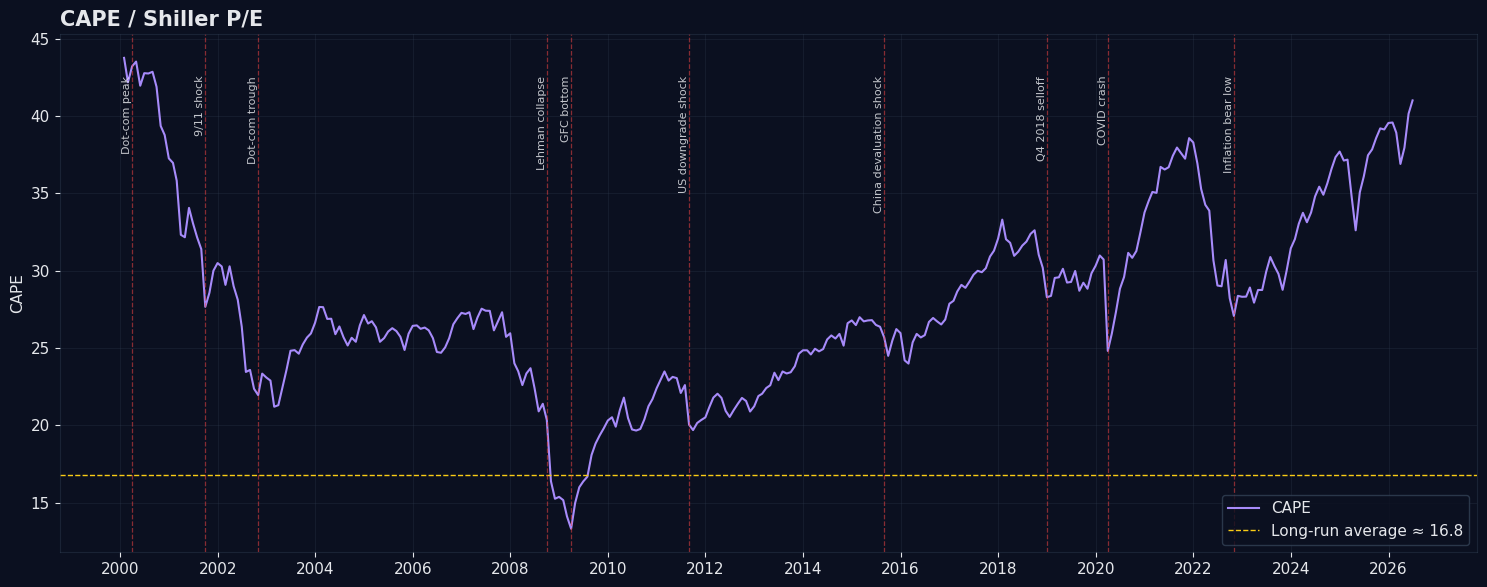

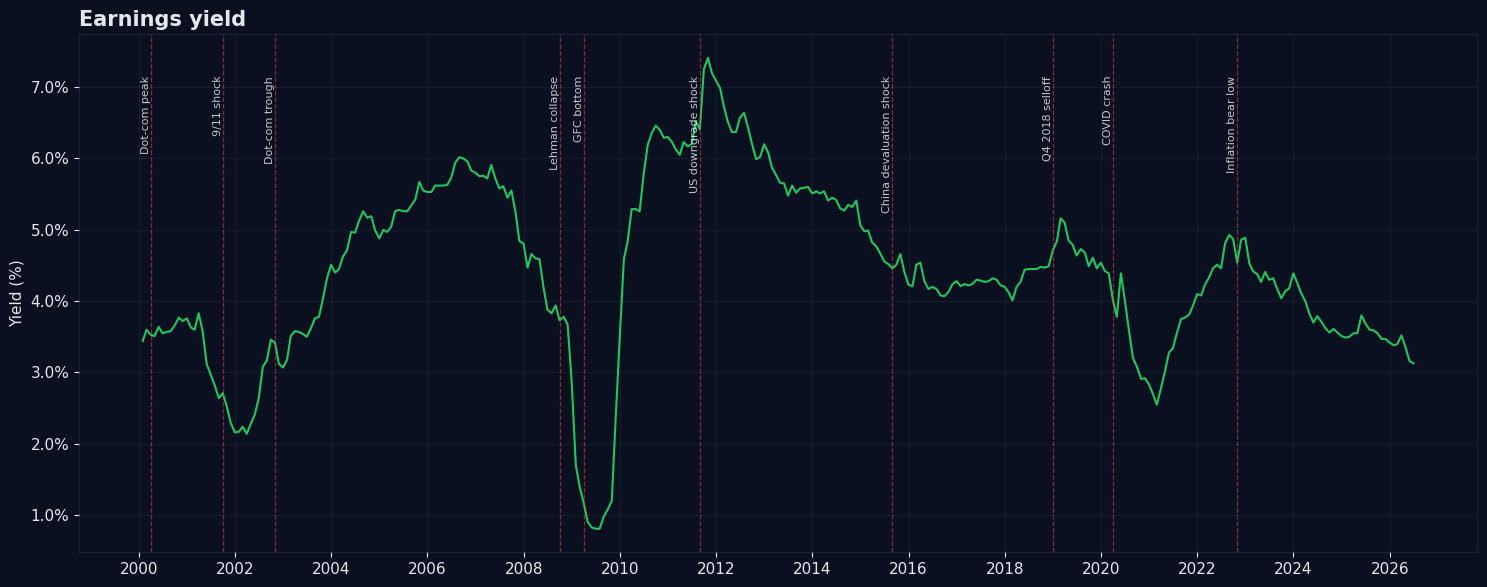

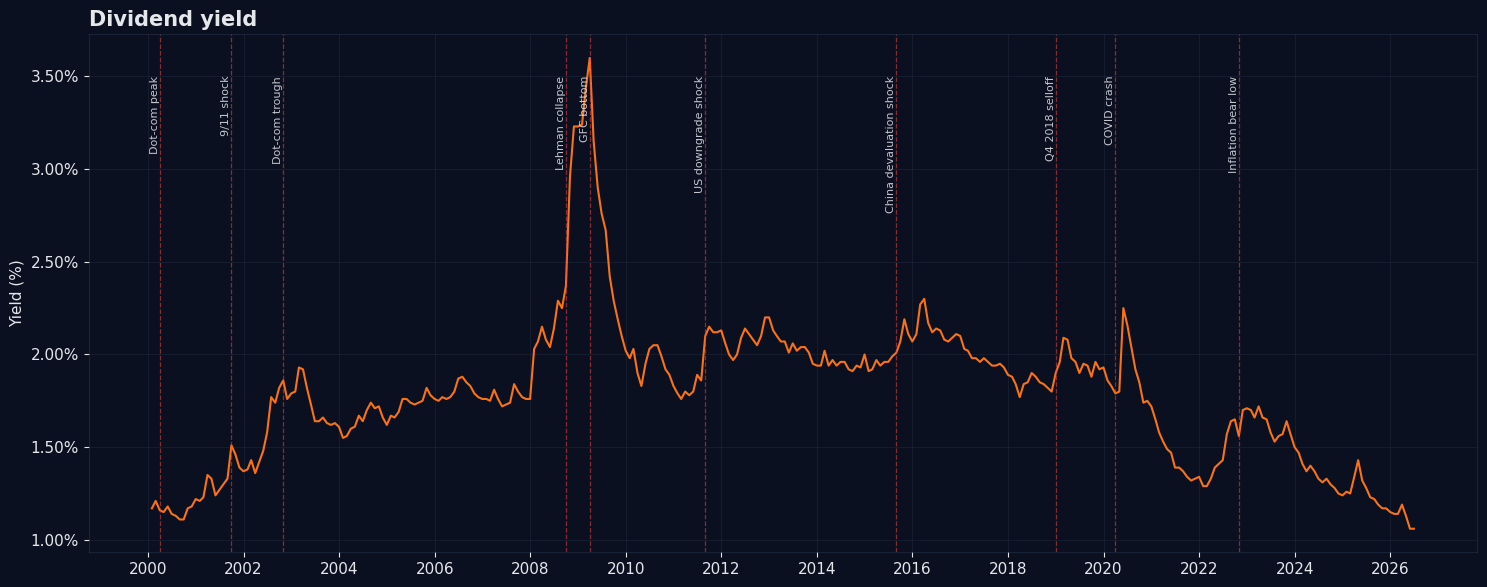

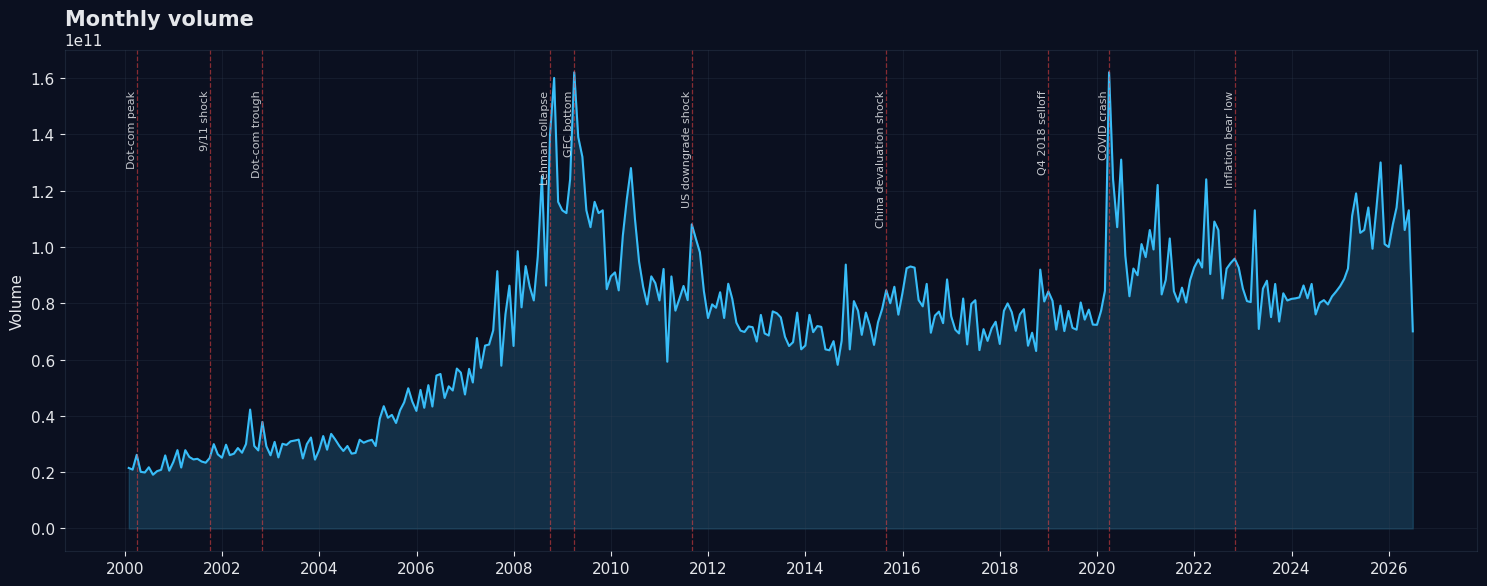

In [5]:
# Every plot below is a separate 1×1 single-panel figure.

plot_specs = [
    ('SP500_Close', 'S&P 500 close', 'Index level', '01_sp500_close.png', ACCENT, None, None, True, False),
    ('SP500_Open', 'S&P 500 open', 'Index level', '02_sp500_open.png', ORANGE, None, None, False, False),
    ('Monthly_Return', 'Monthly return', 'Return', '03_monthly_return.png', GREEN, 0, 'Zero return', False, True),
    ('Rolling_12M_Return', 'Rolling 12-month return', 'Return (%)', '04_rolling_12m_return.png', ACCENT, 0, 'Zero return', False, True),
    ('Rolling_12M_Vol', 'Rolling 12-month volatility', 'Annualized volatility (%)', '05_rolling_12m_vol.png', PURPLE, None, None, True, True),
    ('Drawdown', 'S&P 500 drawdown', 'Drawdown (%)', '06_drawdown.png', RED, 0, 'Previous peak', True, True),
    ('Trailing_PE', 'Trailing P/E', 'P/E ratio', '07_trailing_pe.png', GOLD, None, None, False, False),
    ('CAPE', 'CAPE / Shiller P/E', 'CAPE', '08_cape.png', PURPLE, 16.8, 'Long-run average ≈ 16.8', False, False),
    ('Earnings_Yield', 'Earnings yield', 'Yield (%)', '09_earnings_yield.png', GREEN, None, None, False, True),
    ('Dividend_Yield', 'Dividend yield', 'Yield (%)', '10_dividend_yield.png', ORANGE, None, None, False, True),
    ('Volume', 'Monthly volume', 'Volume', '11_volume.png', ACCENT, None, None, True, False),
]

for col, title, ylabel, filename, color, hline, hline_label, fill, percent in plot_specs:
    if col in master.columns and master[col].notna().sum() > 0:
        plot_single_series(master[col], title, ylabel, filename, color, hline, hline_label, fill, percent)
    else:
        print(f'Skipping {title}: {col} not available in CSV.')


## 5. Correlation matrix — available columns only

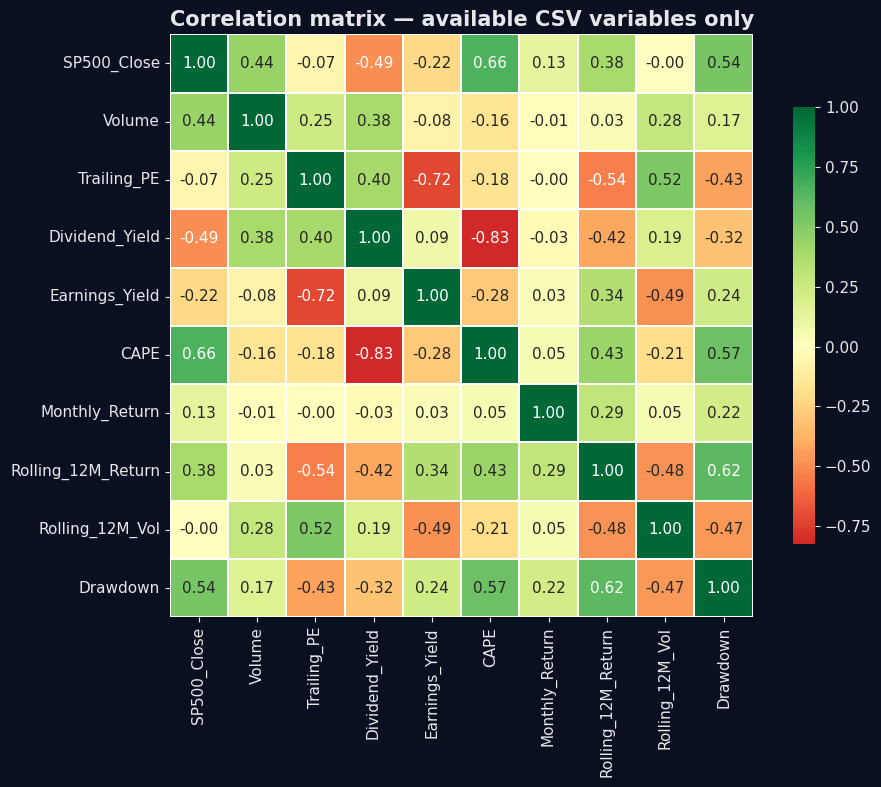

In [6]:
corr_cols = [
    c for c in stat_cols
    if c not in ['SP500_Open'] and master[c].notna().sum() >= 24
]

if len(corr_cols) >= 2:
    corr = master[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)  # 1×1 single panel only
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        center=0,
        square=True,
        linewidths=0.3,
        cbar_kws={'shrink': 0.75},
        ax=ax
    )
    ax.set_title('Correlation matrix — available CSV variables only', loc='left', fontweight='bold')
    save_single_panel(fig, '12_correlation_matrix.png')
else:
    print('Correlation matrix skipped: fewer than two available columns.')


## 6. Outlier analysis — available columns only

In [7]:
OUTLIER_COLS = [
    c for c in stat_cols
    if c not in ['SP500_Close', 'SP500_Open', 'Volume'] and master[c].notna().sum() >= 24
]

print('Outlier columns used:')
print(OUTLIER_COLS)

outlier_summary = []

for col in OUTLIER_COLS:
    s = master[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_outliers = ((s < lower) | (s > upper)).sum()

    z = np.abs(stats.zscore(s, nan_policy='omit'))
    z_outliers = int((z > 3).sum())

    outlier_summary.append({
        'Variable': col,
        'Observations': int(s.count()),
        'IQR_Outliers': int(iqr_outliers),
        'Zscore_gt_3': z_outliers,
        'Min': round(float(s.min()), 4),
        'Max': round(float(s.max()), 4),
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df)


Outlier columns used:
['Trailing_PE', 'Dividend_Yield', 'Earnings_Yield', 'CAPE', 'Monthly_Return', 'Rolling_12M_Return', 'Rolling_12M_Vol', 'Drawdown']


,Variable,Observations,IQR_Outliers,Zscore_gt_3,Min,Max
0,Trailing_PE,318,20,9,13.0078,122.4128
1,Dividend_Yield,318,10,7,1.0600,3.6000
2,Earnings_Yield,318,5,0,0.8100,7.4100
3,CAPE,318,6,0,13.3200,43.7700
4,Monthly_Return,317,5,2,-0.1694,0.1268
5,Rolling_12M_Return,306,13,1,-44.7562,53.7145
6,Rolling_12M_Vol,306,0,0,3.8554,30.4178
7,Drawdown,318,1,1,-52.5559,0.0000


## 7. Single-panel boxplots

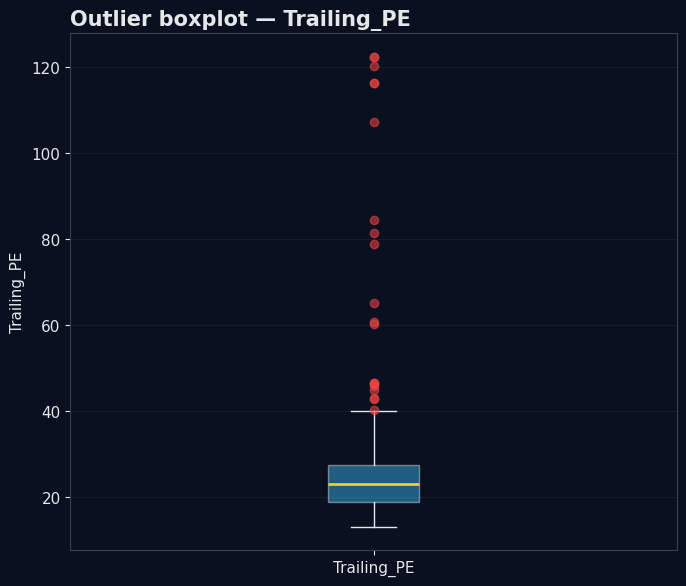

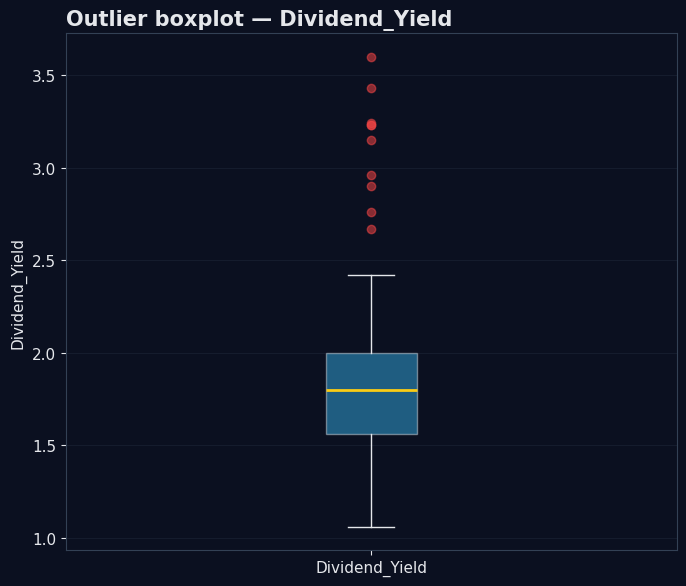

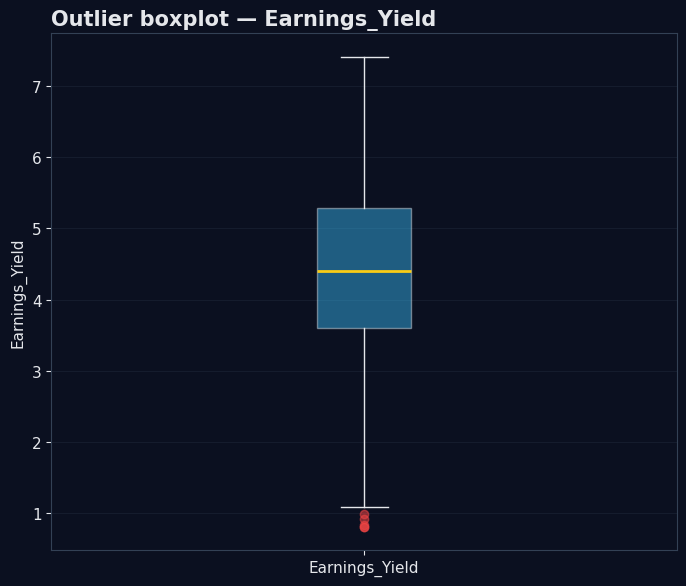

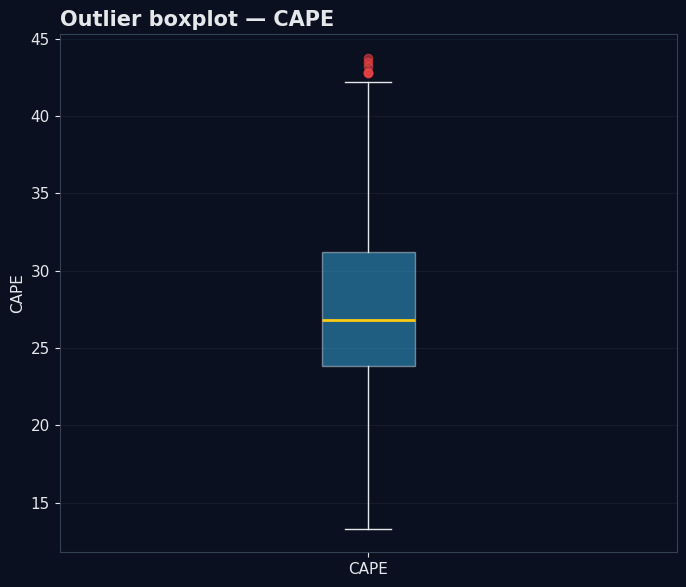

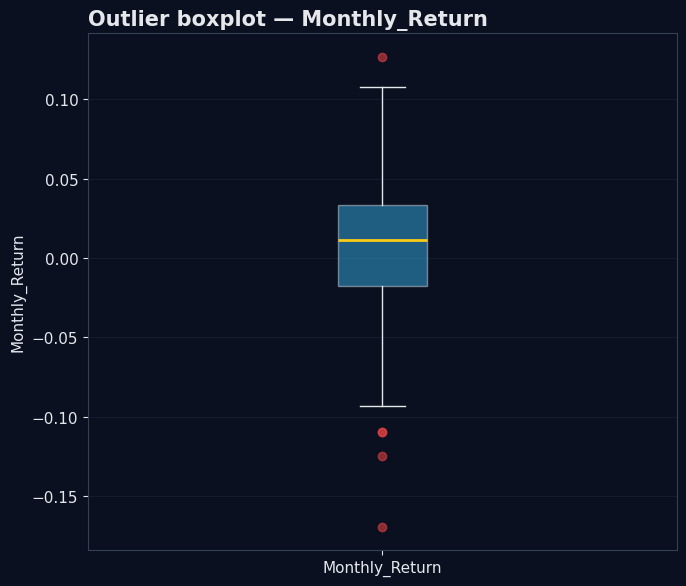

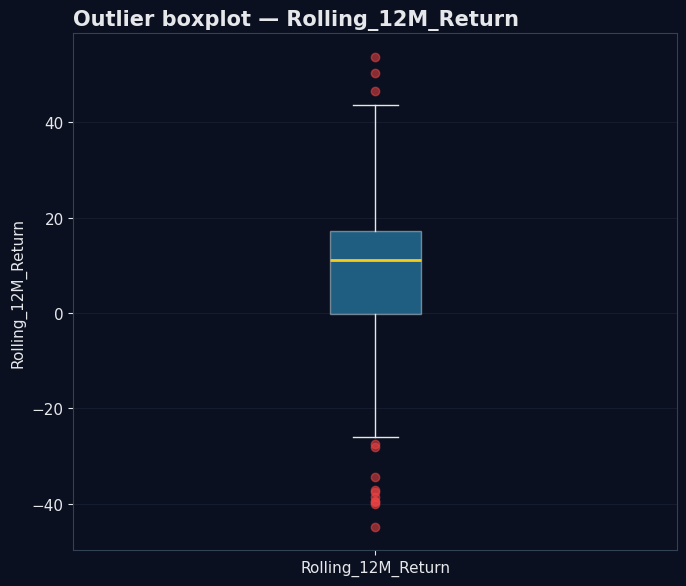

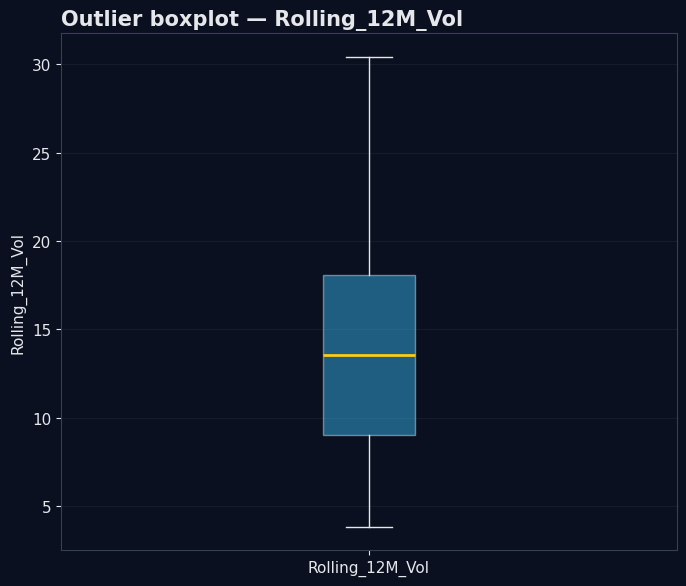

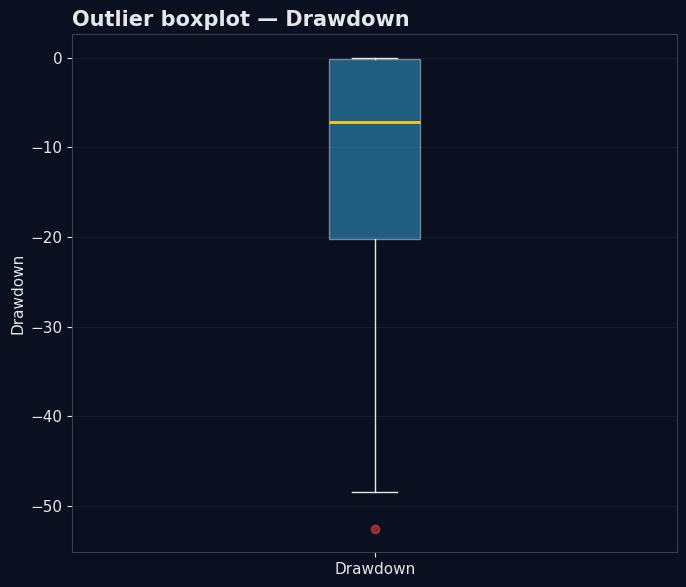

In [8]:
for col in OUTLIER_COLS:
    s = master[col].dropna()
    if s.empty:
        continue

    fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)  # 1×1 single panel only
    ax.boxplot(
        s.values,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor=ACCENT, alpha=0.45, color=FG),
        medianprops=dict(color=GOLD, linewidth=2),
        whiskerprops=dict(color=FG),
        capprops=dict(color=FG),
        flierprops=dict(marker='o', markerfacecolor=RED, markeredgecolor=RED, alpha=0.55)
    )
    ax.set_title(f'Outlier boxplot — {col}', loc='left', fontweight='bold')
    ax.set_ylabel(col)
    ax.set_xticks([1])
    ax.set_xticklabels([col])
    ax.grid(True, alpha=0.25, axis='y')
    save_single_panel(fig, f'boxplot_{col}.png')


## 8. Monthly return distribution

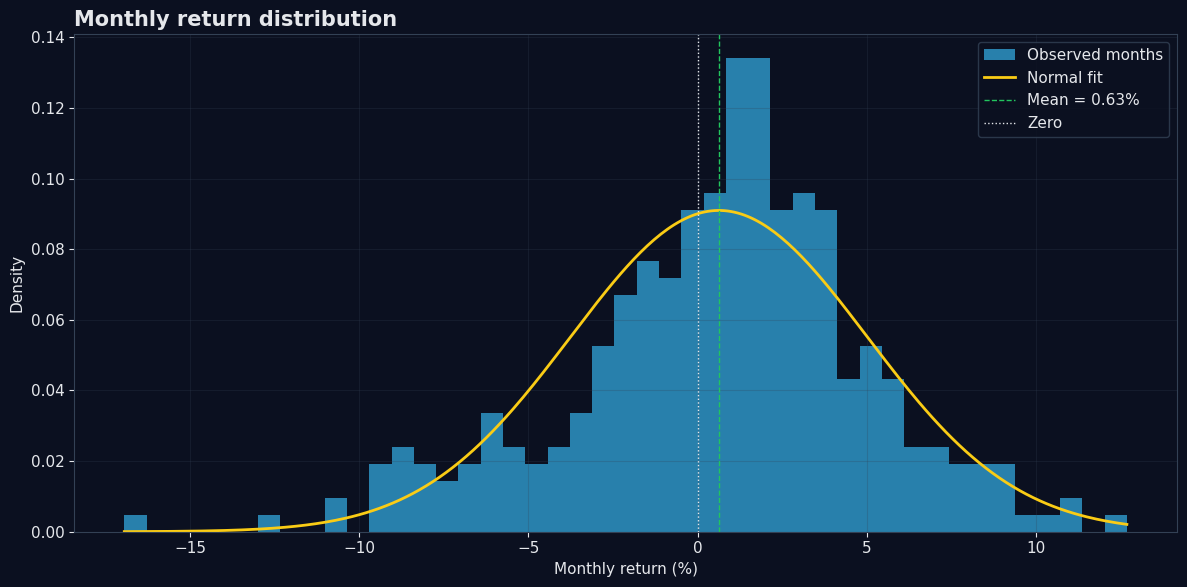

In [9]:
if 'Monthly_Return' in master.columns and master['Monthly_Return'].dropna().size > 10:
    ret = master['Monthly_Return'].dropna() * 100

    fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)  # 1×1 single panel only
    ax.hist(ret, bins=45, alpha=0.65, density=True, color=ACCENT, label='Observed months')

    xr = np.linspace(ret.min(), ret.max(), 300)
    ax.plot(xr, stats.norm.pdf(xr, ret.mean(), ret.std()), color=GOLD, lw=2, label='Normal fit')

    ax.axvline(ret.mean(), color=GREEN, ls='--', lw=1, label=f'Mean = {ret.mean():.2f}%')
    ax.axvline(0, color=FG, ls=':', lw=1, label='Zero')
    ax.set_title('Monthly return distribution', loc='left', fontweight='bold')
    ax.set_xlabel('Monthly return (%)')
    ax.set_ylabel('Density')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.25)
    save_single_panel(fig, 'return_distribution.png')
else:
    print('Return distribution skipped: Monthly_Return unavailable.')


## 9. Composite outlier score

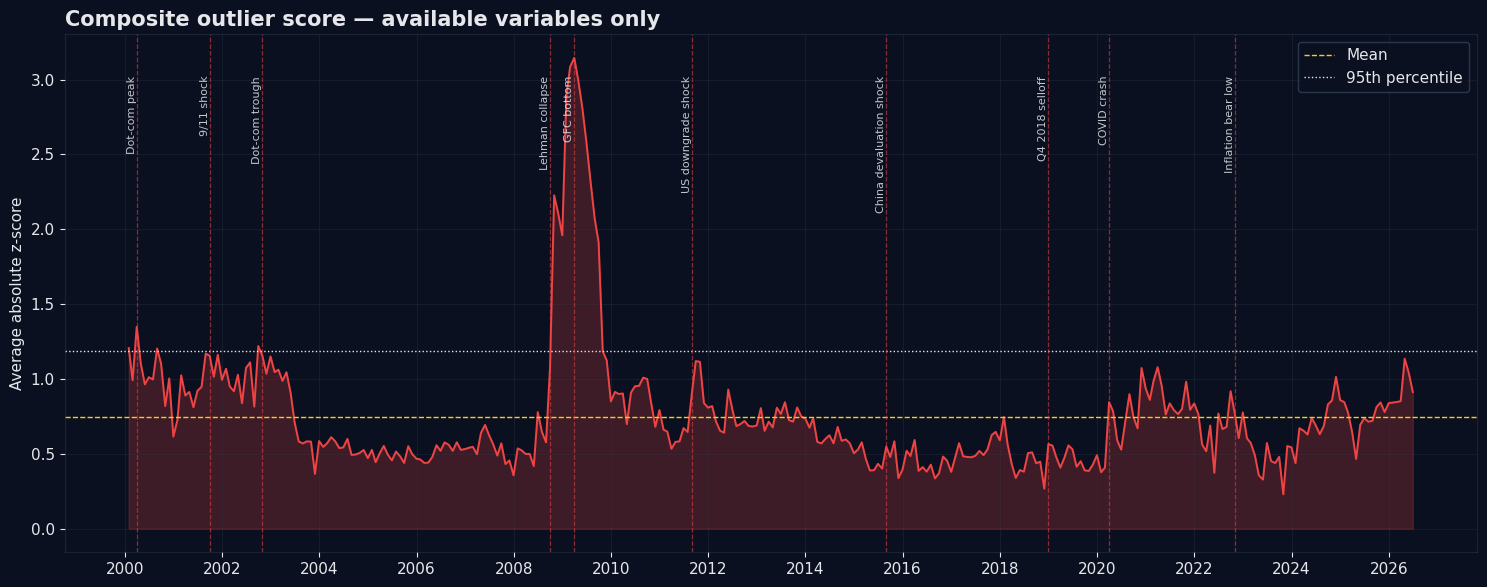

,Composite_Z
Date,
2009-03-31,3.145263
2009-02-28,3.085672
2009-04-30,2.995431
2009-01-31,2.893577
2009-05-31,2.809459
2009-06-30,2.584667
2009-07-31,2.323555
2008-10-31,2.226943
2008-11-30,2.107637


In [10]:
z_df = pd.DataFrame(index=master.index)

for col in OUTLIER_COLS:
    s = master[col].dropna()
    if s.size < 12:
        continue
    z_series = pd.Series(
        np.abs(stats.zscore(s, nan_policy='omit')),
        index=s.index,
        name=f'Z_{col}'
    )
    z_df = z_df.join(z_series, how='left')

if z_df.dropna(how='all').empty:
    print('Composite outlier score skipped: no outlier columns available.')
else:
    z_df['Composite_Z'] = z_df.mean(axis=1, skipna=True)
    comp = z_df['Composite_Z'].dropna()

    fig, ax = plt.subplots(figsize=(15, 6), facecolor=BG)  # 1×1 single panel only
    ax.plot(comp.index, comp.values, color=RED, lw=1.4)
    ax.fill_between(comp.index, comp.values, alpha=0.22, color=RED)
    ax.axhline(comp.mean(), color=GOLD, ls='--', lw=1.0, label='Mean')
    ax.axhline(comp.quantile(0.95), color=FG, ls=':', lw=1.0, label='95th percentile')
    annotate_crashes(ax, comp.index)
    ax.set_title('Composite outlier score — available variables only', loc='left', fontweight='bold')
    ax.set_ylabel('Average absolute z-score')
    ax.legend(loc='best')
    format_time_axis(ax)
    save_single_panel(fig, 'composite_outlier_score.png')

    top_outlier_months = comp.sort_values(ascending=False).head(15).to_frame('Composite_Z')
    display(top_outlier_months)


## 10. Final dataset export

In [11]:
OUTPUT_DATA = 'sp500_csv_master_available_only.csv'
master.to_csv(OUTPUT_DATA)
print(f'Saved final available-only dataset to: {OUTPUT_DATA}')
print('Final columns:')
print(list(master.columns))


Saved final available-only dataset to: sp500_csv_master_available_only.csv
Final columns:
['SP500_Close', 'SP500_Open', 'Volume', 'Trailing_PE', 'Dividend_Yield', 'Earnings_Yield', 'CAPE', 'Monthly_Return', 'Rolling_12M_Return', 'Rolling_12M_Vol', 'Drawdown']


---
## Notes

This notebook intentionally removes unavailable variables such as historical Forward P/E, PEG, P/B, ERP, Treasury yield, D/E, and HHI unless they are actually present in the uploaded CSV. The uploaded CSV contains S&P 500 close/open/volume, trailing P/E, dividend yield, earnings yield, and CAPE, so the analysis is restricted to those plus derived return/risk variables.
